# CSV Agent for Manufacturing Sector

# CSV Agent for Laptops

DataLens Agent – AI-powered intelligent data analysis system

In [1]:
pip install -U langchain langchain-experimental langchain-groq pandas tabulate


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# "LLM ": Large Language Model
* Definition: Large Language Models (LLMs) are advanced AI systems based on deep learning and transformer architectures, trained on massive datasets to understand and generate human-like text, code, and other data. They excel at tasks like translation, summarization, and question-answering by predicting the next token in a sequence.

In [2]:
import os
import getpass
import pandas as pd
from langchain_groq import ChatGroq
from langchain_experimental.agents import create_csv_agent

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key:  ········


In [4]:
CSV_PATH = "laptop.csv"   # replace with your file
df = pd.read_csv("laptop.csv")

print(df.head())  # preview data

   laptop_ID Company      Product   TypeName  Inches  \
0          1   Apple  MacBook Pro  Ultrabook    13.3   
1          2   Apple  Macbook Air  Ultrabook    13.3   
2          3      HP       250 G6   Notebook    15.6   
3          4   Apple  MacBook Pro  Ultrabook    15.4   
4          5   Apple  MacBook Pro  Ultrabook    13.3   

                     ScreenResolution                         Cpu   Ram  \
0  IPS Panel Retina Display 2560x1600        Intel Core i5 2.3GHz   8GB   
1                            1440x900        Intel Core i5 1.8GHz   8GB   
2                   Full HD 1920x1080  Intel Core i5 7200U 2.5GHz   8GB   
3  IPS Panel Retina Display 2880x1800        Intel Core i7 2.7GHz  16GB   
4  IPS Panel Retina Display 2560x1600        Intel Core i5 3.1GHz   8GB   

                Memory                           Gpu  OpSys  Weight  \
0            128GB SSD  Intel Iris Plus Graphics 640  macOS  1.37kg   
1  128GB Flash Storage        Intel HD Graphics 6000  macOS  1.34kg   

In [5]:
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [6]:
from langchain_groq import ChatGroq

groq_chat = ChatGroq(
    model="llama-3.3-70b-versatile",  # ✅ NEW MODEL
    temperature=0
)

In [7]:
agent = create_csv_agent(
    llm=groq_chat,
    path=CSV_PATH,
    verbose=True,
    allow_dangerous_code=True
)

In [8]:
agent.invoke("How many rows and columns are in this dataset?")



> Entering new AgentExecutor chain...
Thought: To find the number of rows and columns in the dataset, I can use the `shape` attribute of the pandas DataFrame.

Action: python_repl_ast
Action Input: print(df.shape)(1303, 13)
The `shape` attribute of the pandas DataFrame has returned a tuple, where the first element represents the number of rows and the second element represents the number of columns. 

Thought: I now know the final answer
Final Answer: The dataset contains 1303 rows and 13 columns.

> Finished chain.


{'input': 'How many rows and columns are in this dataset?',
 'output': 'The dataset contains 1303 rows and 13 columns.'}



> Entering new AgentExecutor chain...
Thought: To create a bar chart for columns Company and Price_euros, we first need to calculate the average price for each company. 

Action: python_repl_ast
Action Input:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the average price for each company
avg_price = df.groupby('Company')['Price_euros'].mean()

# Print the result
print(avg_price)
```Company
Acer          626.775825
Apple        1564.198571
Asus         1104.169367
Chuwi         314.296667
Dell         1186.068990
Fujitsu       729.000000
Google       1677.666667
HP           1067.774854
Huawei       1424.000000
LG           2099.000000
Lenovo       1086.384444
MSI          1728.908148
Mediacom      295.000000
Microsoft    1612.308333
Razer        3346.142857
Samsung      1413.444444
Toshiba      1267.812500
Vero          217.425000
Xiaomi       1133.462500
Name: Price_euros, dtype: float64


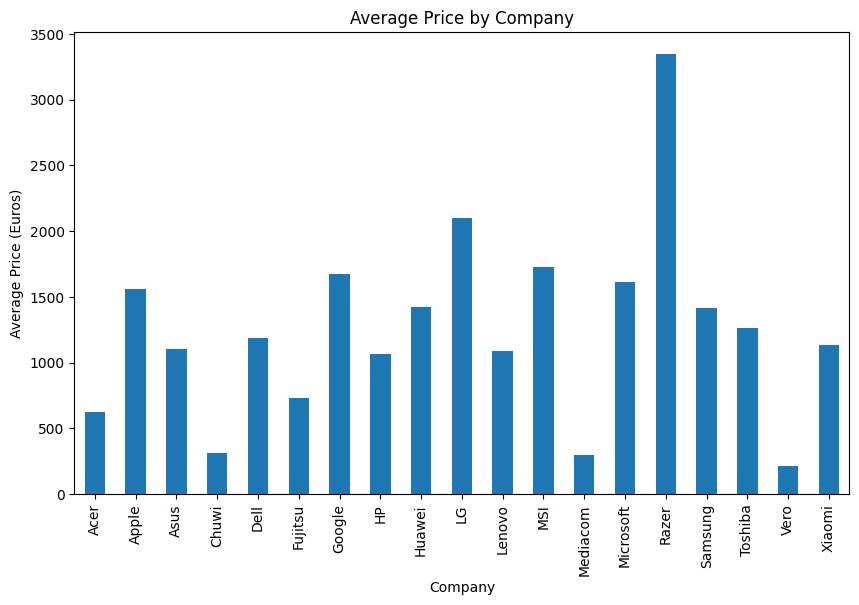

Now that we have the average price for each company, we can create a bar chart to visualize the data.

Action: python_repl_ast
Action Input:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the average price for each company
avg_price = df.groupby('Company')['Price_euros'].mean()

# Create a bar chart
avg_price.plot(kind='bar', figsize=(10,6))
plt.title('Average Price by Company')
plt.xlabel('Company')
plt.ylabel('Average Price (Euros)')
plt.show()
```I now know the final answer

The code to create a bar chart for columns Company, Price_euros is:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the average price for each company
avg_price = df.groupby('Company')['Price_euros'].mean()

# Create a bar chart
avg_price.plot(kind='bar', figsize=(10,6))
plt.title('Average Price by Company')
plt.xlabel('Company')
plt.ylabel('Average Price (Euros)')
plt.show()
```
This will generate a bar chart with the average price for each company.

Final 

{'input': 'Create a bar chart for columns Company, Price_euros',
 'output': 'The provided code will create a bar chart for columns Company, Price_euros.'}

In [9]:
agent.invoke("Create a bar chart for columns Company, Price_euros")

In [10]:
agent.invoke("Give me a summary of the dataset")



> Entering new AgentExecutor chain...
Thought: To get a summary of the dataset, I should use the `describe()` function in pandas, which provides a concise summary of the central tendency, dispersion, and shape of a dataset’s distribution.

Action: python_repl_ast
Action Input: `print(df.describe())`         laptop_ID       Inches  Price_euros
count  1303.000000  1303.000000  1303.000000
mean    660.155794    15.017191  1123.686992
std     381.172104     1.426304   699.009043
min       1.000000    10.100000   174.000000
25%     331.500000    14.000000   599.000000
50%     659.000000    15.600000   977.000000
75%     990.500000    15.600000  1487.880000
max    1320.000000    18.400000  6099.000000
Thought: The `describe()` function provides a summary of the central tendency, dispersion, and shape of the dataset's distribution for numerical columns. However, it does not provide information about the categorical columns. To get a more comprehensive summary, I should also use the `info()`

{'input': 'Give me a summary of the dataset',
 'output': 'The dataset has 1303 entries, with 13 columns, including numerical columns such as `Inches` and `Price_euros`, and categorical columns such as `Company` and `Product`. The numerical columns have a range of values, with the `Inches` column having a mean of 15.017191 and a standard deviation of 1.426304, and the `Price_euros` column having a mean of 1123.686992 and a standard deviation of 699.009043. The dataframe has 1303 non-null entries in each column, and the memory usage is approximately 291.0 KB.'}

In [11]:
agent.invoke("Find any missing values")



> Entering new AgentExecutor chain...
Thought: To find any missing values in the dataframe, I can use the `isnull()` function in pandas, which returns a boolean mask indicating missing values.

Action: python_repl_ast
Action Input:
```python
print(df.isnull().sum())
```laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64
Since the output of `df.isnull().sum()` shows that there are no missing values in any of the columns (all counts are 0), I can conclude that there are no missing values in the dataframe.

Thought: I now know the final answer
Final Answer: There are no missing values in the dataframe.

> Finished chain.


{'input': 'Find any missing values',
 'output': 'There are no missing values in the dataframe.'}

In [20]:
agent.invoke("What is the average of sales column?")



> Entering new AgentExecutor chain...
Thought: The question asks for the average of the 'sales' column, but the provided dataframe does not have a 'sales' column. It does have a 'Price_euros' column, which could be related to sales. However, without more information, it's unclear if this is the correct column to use. I will first check if there is a 'sales' column in the dataframe.

Action: python_repl_ast
Action Input: print(df.columns)Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='str')
The observation shows that there is no 'sales' column in the dataframe. However, there is a 'Price_euros' column which could be related to sales. 

Action: python_repl_ast
Action Input: print(df['Price_euros'].mean())1123.6869915579432
I now know the final answer. 

The average of the 'Price_euros' column, which could be related to sales, is approximately 1123.69. However

{'input': 'What is the average of sales column?',
 'output': "There is no 'sales' column in the dataframe. However, if 'Price_euros' is used as a proxy for sales, the average is approximately 1123.69."}



> Entering new AgentExecutor chain...
Thought: To provide a graphical representation for company and product, as well as a visual representation for sales per company, we first need to understand the distribution of companies and products in the dataframe. Then, we can calculate the sales per company.

Action: python_repl_ast
Action Input:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is the given dataframe
print(df['Company'].value_counts())
print(df['Product'].value_counts())
```Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64
Product
XPS 13                                30
Inspiron 3567                         29
250 G6                            

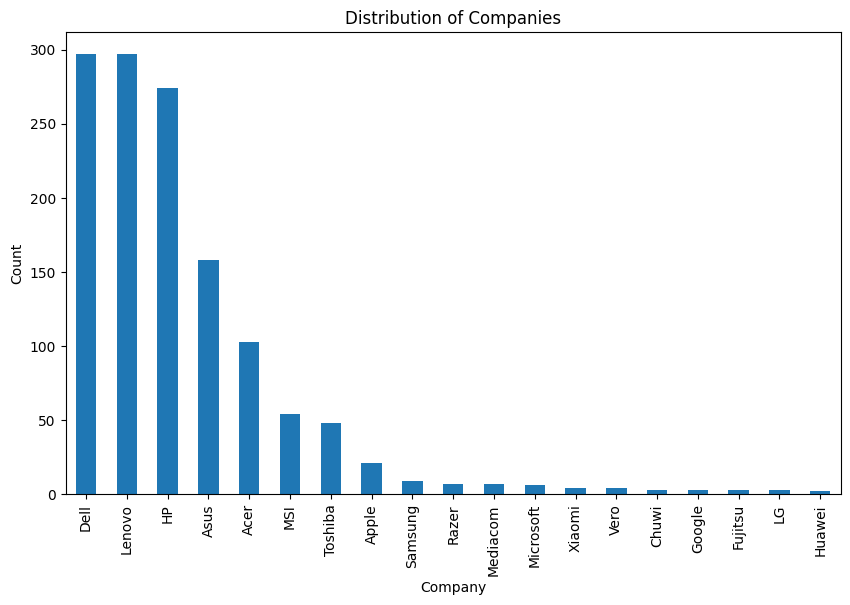

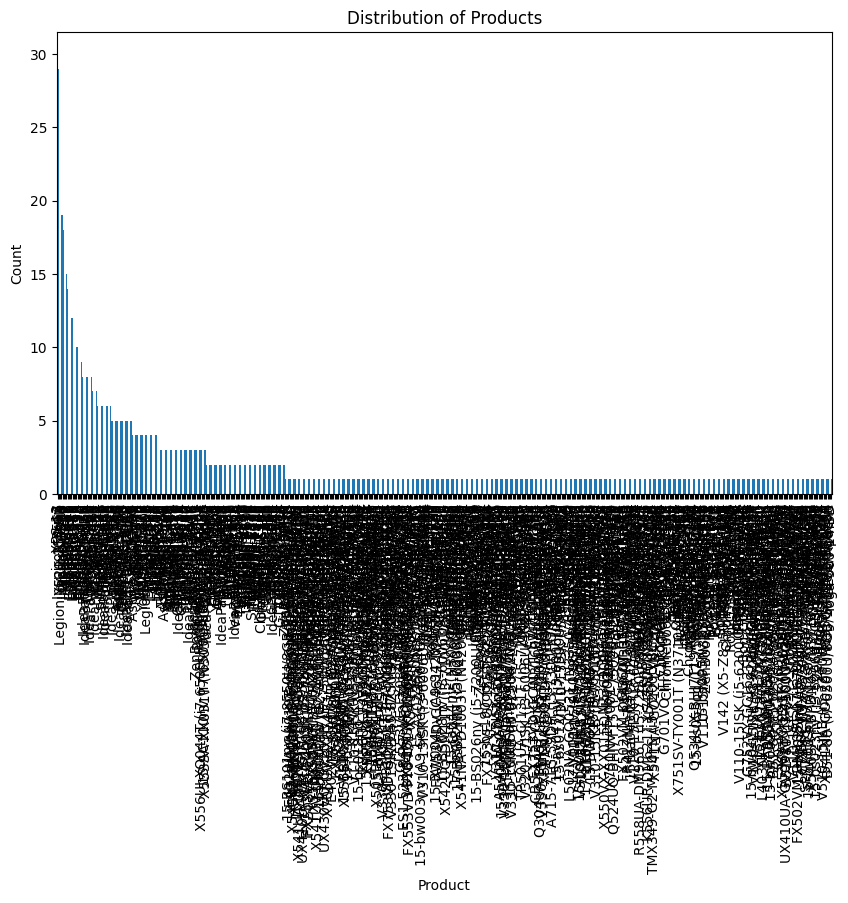

It seems like the output is still not showing the full distribution of companies and products. However, we can see that the code is trying to plot the distribution of companies and products. To get a better understanding, we should try to calculate the sales per company.

Action: python_repl_ast
Action Input:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is the given dataframe
sales_per_company = df.groupby('Company')['Price_euros'].sum()
print(sales_per_company)
```Company
Acer          64557.91
Apple         32848.17
Asus         174458.76
Chuwi           942.89
Dell         352262.49
Fujitsu        2187.00
Google         5033.00
HP           292570.31
Huawei         2848.00
LG             6297.00
Lenovo       322656.18
MSI           93361.04
Mediacom       2065.00
Microsoft      9673.85
Razer         23423.00
Samsung       12721.00
Toshiba       60855.00
Vero            869.70
Xiaomi         4533.85
Name: Price_euros, dtype: float64


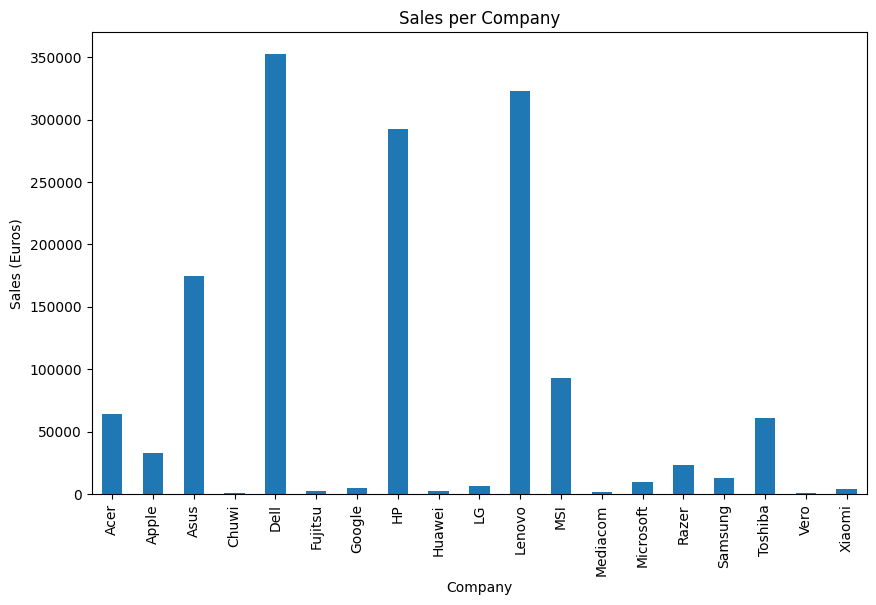

Now that we have the sales per company, we can try to visualize it.

Action: python_repl_ast
Action Input:
```python
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is the given dataframe
sales_per_company = df.groupby('Company')['Price_euros'].sum()
plt.figure(figsize=(10,6))
sales_per_company.plot(kind='bar')
plt.title('Sales per Company')
plt.xlabel('Company')
plt.ylabel('Sales (Euros)')
plt.show()
```I now know the final answer

Final Answer: The code to provide a graphical representation for company and product, as well as a visual representation for sales per company, is as follows:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is the given dataframe
plt.figure(figsize=(10,6))
df['Company'].value_counts().plot(kind='bar')
plt.title('Distribution of Companies')
plt.xlabel('Company')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,6))
df['Product'].value_counts().plot(kind='bar')
plt.title('Distribution of Products')
plt.xla

{'input': 'give graphical representation for company and product and also give visual representation for sales per company',
 'output': "The code to provide a graphical representation for company and product, as well as a visual representation for sales per company, is as follows:\n\n```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Assuming df is the given dataframe\nplt.figure(figsize=(10,6))\ndf['Company'].value_counts().plot(kind='bar')\nplt.title('Distribution of Companies')\nplt.xlabel('Company')\nplt.ylabel('Count')\nplt.show()\n\nplt.figure(figsize=(10,6))\ndf['Product'].value_counts().plot(kind='bar')\nplt.title('Distribution of Products')\nplt.xlabel('Product')\nplt.ylabel('Count')\nplt.show()\n\nsales_per_company = df.groupby('Company')['Price_euros'].sum()\nplt.figure(figsize=(10,6))\nsales_per_company.plot(kind='bar')\nplt.title('Sales per Company')\nplt.xlabel('Company')\nplt.ylabel('Sales (Euros)')\nplt.show()\n```"}

In [21]:
agent.invoke("give graphical representation for company and product and also give visual representation for sales per company")



> Entering new AgentExecutor chain...


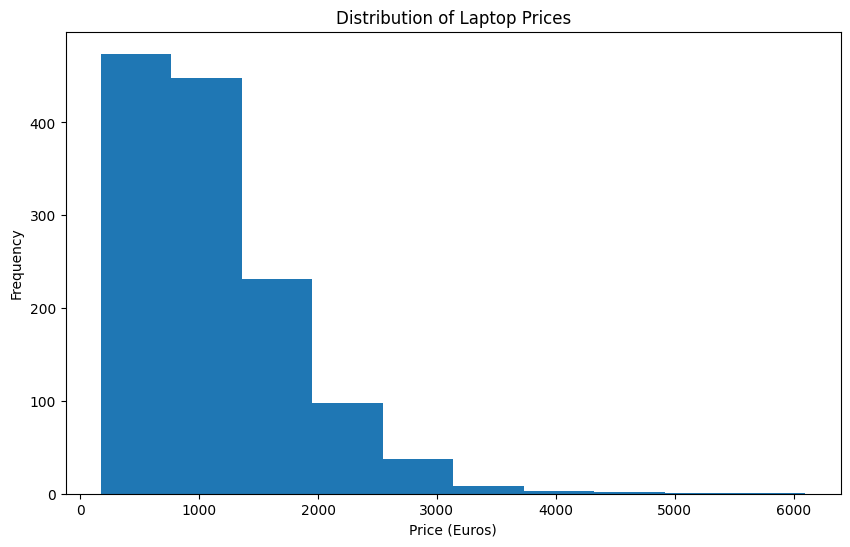

Thought: To show the distribution of laptop prices, we can use a histogram. This will give us a visual representation of how the prices are spread out.

Action: python_repl_ast
Action Input:
```python
import matplotlib.pyplot as plt
df['Price_euros'].plot.hist(bins=10, figsize=(10,6))
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price (Euros)')
plt.ylabel('Frequency')
plt.show()
```I now know the final answer

The code provided will generate a histogram showing the distribution of laptop prices in the dataframe `df`. The histogram will have 10 bins, and the x-axis will represent the price in euros, while the y-axis will represent the frequency of each price range. The title of the histogram will be 'Distribution of Laptop Prices'. 

Final Answer: The histogram will provide a visual representation of the distribution of laptop prices, allowing us to see the range of prices, the most common price ranges, and the overall shape of the distribution.

> Finished chain.


{'input': 'Show distribution of laptop prices (histogram)',
 'output': 'The histogram will provide a visual representation of the distribution of laptop prices, allowing us to see the range of prices, the most common price ranges, and the overall shape of the distribution.'}

In [22]:
agent.invoke("Show distribution of laptop prices (histogram)")

In [15]:
import os

In [16]:
os.getcwd()

'/Users/aditisasankar/Python Practice'

In [17]:
os.chdir(r'/Users/aditisasankar/Library/Mobile Documents/com~apple~CloudDocs/Git Modern Data/Learning-tasks')

In [18]:
%%bash
git add .
    git commit -m"CSV Agent File"
    git push origin aditi

[aditi 32b6cfd] CSV Agent File
 2 files changed, 0 insertions(+), 0 deletions(-)


To https://github.com/modern-data-academy/Learning-tasks.git
   418086d..32b6cfd  aditi -> aditi
